# AI 면접관 변환기 — QLoRA 4bit

이 노트북은 기존 `test.py`를 기준으로 다음 문제를 막도록 정리한 개선판입니다.

1. **LoRA adapter가 붙었지만 trainable이 0개가 되는 문제**를 `ensure_lora_trainable()`로 강제 점검합니다.
2. `prompt` / `completion` 컬럼만 `SFTTrainer`에 넘겨서 데이터 포맷 해석을 명확하게 합니다.
3. `completion_only_loss=True`가 실제로 completion 토큰에만 걸리는지 확인하는 진단 셀을 넣었습니다.
4. 작은 데이터셋에서 loss가 출렁이는 문제를 고려해 `max_steps`, `logging_steps`, `warmup_ratio`, `max_grad_norm`을 안정적으로 조정했습니다.
5. Qwen 계열 chat template의 EOS 토큰이 `<|im_end|>`인지 확인하고 `SFTConfig(eos_token=...)`에 명시합니다.

> 권장 실행 순서: **커널 재시작 → 위에서부터 순서대로 Run All**.  
> LoRA 설정 셀을 중복 실행하면 adapter가 중첩될 수 있으므로, 중간부터 다시 돌릴 때는 모델 로드 셀부터 다시 실행하세요.


In [1]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

QLoRA 4bit 학습은 CUDA GPU가 필요합니다. BF16을 지원하는 GPU면 BF16을 사용하고, 아니면 FP16으로 자동 전환합니다.


In [2]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 QLoRA 4bit CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.3
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

아래 설치 셀은 최초 1회만 사용하세요. 이미 환경이 준비되어 있으면 건너뛰면 됩니다.


In [3]:
import datasets

In [4]:
import transformers
import peft
import trl
import bitsandbytes
import accelerate


print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


In [5]:
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

## 2. 모델과 토크나이저 로드 — NF4 4bit QLoRA

`MODEL_ID`만 바꾸면 1.7B 또는 4B 계열 모두 같은 구조로 실험할 수 있습니다. 6GB VRAM에서는 1.7B가 안전하고, 더 큰 GPU에서는 4B도 시도할 수 있습니다.


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-1.7B"  # 예: "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig( # 사용할 양자화 설정
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4", # 양자화한 형태
    bnb_4bit_compute_dtype=COMPUTE_DTYPE, # 역양자화했을때 형태
    bnb_4bit_use_double_quant=True, # 양자화 상수(파라미터마다 존재)를 추가 양자화
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab() # {토큰 문자열: 토큰 ID} 형태로 저장
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

# 지정한 언어 모델을 4비트 양자화 상태로 불러오기 위한 함수
def load_causal_lm_4bit(model_id: str):
    kwargs = dict(
        quantization_config=bnb_config, # 사용할 양자화 설정 사용
        device_map={"": 0},
        trust_remote_code=True, # 작성자 신뢰
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs) # 5점대 -> 우리가쓸거
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs) # 4점대

model = load_causal_lm_4bit(MODEL_ID) # 모델 양자화 상태로 호출
model.config.use_cache = False # 학습중에느 KV캐시를 끈다. (추론할때 사용)

print("모델 로드 완료")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

모델 로드 완료
EOS_TOKEN: '<|im_end|>' id= 151645
PAD_TOKEN: '<|endoftext|>' id= 151643
현재 GPU 메모리 사용량: 1.26 GB


## 3. 공통 유틸리티

핵심은 `ensure_lora_trainable()`입니다. 사용자가 겪은 `LoRA params는 있는데 Trainable LoRA params가 0개`인 상태를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


In [7]:
def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False, # 결과를 토큰이 아닌 문자열로 반환하라
            add_generation_prompt=add_generation_prompt, # assistant가 답변할 차례라는 시작 표시를 붙일지 결정
            enable_thinking=False, # thinking모드 설정 -> 생각하는 과정 보이도록 할지(True) 말지(False)
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str: # thinking 모드가 반환되면 그 부분은 제외하고 답변만 출력
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()


def ask(question: str, max_new_tokens: int = 120, do_sample: bool = False) -> str:
    model.eval()
    messages = [{"role": "user", "content": question}]
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model)) # input 토큰화하기

    # 주요연산은 dtype으로 안정성이 필요한 정밀한 연산은 pytorch 정책에 맡김
    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens, # 새로 생성할 수 있는 최대 토큰수
        do_sample=do_sample, 
        # Ture : 확률이 높을수록 뽑힐 가능성이 높지만 항상 확률이 가장 높은 것만 뽑지는 않음
        # False : 항상 확률이 가장 높은 것을 뽑음
        repetition_penalty=1.10, # 이미 등장한 토큰이 다시 선택될 확률을 낮춤
        no_repeat_ngram_size=3, # 이미 생성된 것과 동일한 토큰을 설정한 만큼 연속으로 만들지 못하게 하는것
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.8, top_p=0.8)
        # temperature 값이 낮을수록 보수적, 클수록 자유분방
        # top_p : 확률이 높은 순으로 나열해서 누적확률이 설정한 값만큼 되도록 자르고 그 안에서 선택

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


# 학습 가능한 파라미터 수와 전체 파라미터 수 계산
def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total

# lora가 들어간 LoRA 파라미터만 찾아서 개수를 계산
def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total

# LoRA 어댑터가 모델에 제대로 붙어 있고 실제로 학습 가능한 상태인지 확인
# 필요한 경우 LoRA 파라미터가 모델에 존재하지만 업데이트되지 않도록 꺼져 있는 상태를 다시 켠다 (학습상태로 되살린다)
def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before 응답 확인

학습 전 모델의 기본 응답을 저장합니다.


In [8]:
test_questions = [
    "직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.",
    "직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.",
    "직무: 데이터 에널리스트 경험: 공공데이터를 바탕으로 테블로를 이용해서 데이터를 시각화해보았다."
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q)
    before_answers[q] = ans
    print(f"\nQ: {q}\nA: {ans}")
    print("-" * 50)

파인튜닝 전(Before) 응답

Q: 직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.
A: 안녕하세요! 당신은 **Vision AI 모델 개发자**로서 **OpenCV**, **PyTorch**, **LabelMe**를 활용한 **라벨링 → 모델 훈련 → 파인트튜닝** 과정을 경험하셨습니다. 이 경험을 바탕으로 다양한 기술적 역량과 프로젝트 경험을 보유하고 있습니다.

---

### ✅ 주요 역량 및 경험 요약:

1. **라ベル링 (Annotation)**
   - OpenCV와 LabelMe를 활용하여 이미지 데이터에 �
--------------------------------------------------

Q: 직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.
A: 안녕하세요! 당신은 AI 엘리먼트에서 PyTorch를 활용하여 모델 설계와 평가는 경험을 가지고 있습니다. 이 경험을 바탕으로, 아래에 **PyTorch로 모델 구축 및 평사지표 개발**에 대한 설명과 함께 **이력서/자기소개** 형식의 예시를 제공합니다.

---

## ✅ **이력을 정리한 자소**

**직무:** AI 엄니어  
**경험:**  
- **Pytorch 기반 모델 개
--------------------------------------------------

Q: 직무: 데이터 에널리스트 경험: 공공데이터를 바탕으로 테블로를 이용해서 데이터를 시각화해보았다.
A: 안녕하세요! 당신이 공공 데이터를 기반으로 텍스트에서 테이블로 변환하고, 이를 통해 데이터를 그래픽화하는 과정을 설명하신 것 같습니다. 아래는 이 과程에 대한 간단한 설명과 예시입니다.

---

### **1. 직무:**
- **직무:** 데이터 분석 및 시각적 표현  
- **목표:** 공공 자료를 활용하여 테그(테이블) 형태로 정리하고, 그 데이

## 5. 데이터셋 준비

`SFTTrainer`가 가장 안정적으로 해석하도록 최종 학습 데이터는 `prompt`, `completion` 두 컬럼만 남깁니다.  
기존 코드처럼 `instruction`, `response`, `prompt`, `completion`을 모두 넘겨도 동작할 수 있지만, 강의/실습에서는 의도를 명확히 하는 쪽이 좋습니다.


In [9]:
from datasets import load_dataset


raw_dataset = load_dataset(
    "json",
    data_files="datas/ai_interview_sft.jsonl",
    split="train",
)


print("학습 데이터 개수:", len(raw_dataset))
print("컬럼:", raw_dataset.column_names)


sample = raw_dataset[0]
print("SYSTEM:", sample["instruction"])
print("USER:", sample["input"])
print("ASSISTANT:", sample["output"])

학습 데이터 개수: 31
컬럼: ['instruction', 'input', 'output']
SYSTEM: 지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.
USER: 직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.
ASSISTANT: 1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?


In [10]:
def format_example(example):
    prompt = tokenizer.apply_chat_template(
        [
            {
                "role": "system",
                "content": example["instruction"].strip(),
            },
            {
                "role": "user",
                "content": example["input"].strip(),
            },
        ],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    completion = example["output"].strip() + tokenizer.eos_token

    return {
        "prompt": prompt,
        "completion": completion,
    }


dataset = raw_dataset.map(format_example)
train_dataset = dataset.select_columns(["prompt", "completion"])

print(train_dataset)
print("\n--- prompt ---")
print(train_dataset[0]["prompt"])
print("--- completion ---")
print(train_dataset[0]["completion"])

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 31
})

--- prompt ---
<|im_start|>system
지원자의 경험을 바탕으로 실제 역량을 검증할 수 있는 심층 기술면접 질문 3개를 만들어라.<|im_end|>
<|im_start|>user
직무: RAG 개발자
경험: LangChain, Qdrant, BGE 임베딩을 사용해 사내 문서 QA 챗봇을 개발했다. Top-k=5를 사용했다.<|im_end|>
<|im_start|>assistant
<think>

</think>


--- completion ---
1. Qdrant를 선택한 이유를 FAISS와 비교하여 설명해보세요.
2. Top-k=5를 결정할 때 어떤 실험이나 평가 지표를 사용했나요?
3. 임베딩 검색 결과는 관련성이 높지만 최종 답변이 부정확할 때 어느 단계를 우선 점검하겠습니까?<|im_end|>


## 6. LoRA 설정

중요한 순서입니다.

1. `prepare_model_for_kbit_training(model)`
2. `get_peft_model(model, lora_config)`
3. `ensure_lora_trainable(model)`
4. 그 다음에 `SFTTrainer(...)`

`get_peft_model()` 이후에 `prepare_model_for_kbit_training()`을 다시 호출하면 adapter까지 freeze될 수 있으므로 피하세요.


In [11]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

# 순서 : prepare -> loraconfig -> get
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    # 모델이 달라져 target_modules 에러가 나면 아래 한 줄로 대체할 수 있습니다.
    # target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 7. 학습 설정 및 Trainer 생성

40개 데이터셋에서는 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.


In [12]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./outputs/sample_a_sageuk_qlora_improved",

    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=80,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",

    logging_steps=1,
    save_strategy="no",

    bf16=BF16_OK,
    fp16=not BF16_OK,
    optim="paged_adamw_8bit",
    max_length=512,

    # prompt-completion dataset에서는 completion 부분만 loss를 주는 것이 목적에 맞습니다.
    completion_only_loss=True,
    eos_token=EOS_TOKEN,
    report_to="none",

    seed=SEED,
    data_seed=SEED
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 질문 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 사극체 답변 부분 위주로 보입니다.


In [13]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 159)
labels shape   : (1, 159)
loss가 걸리는 token 수: 76

---- decoded labels ----
1. 실험 전에 표본 크기를 계산해야 하는 이유와 필요한 입력값을 설명해보세요.
2. 여러 지표를 동시에 검정할 때 발생하는 다중비교 문제를 어떻게 처리하겠습니까?
3. 통계적으로 유의하지만 실제 효과크기가 매우 작은 결과를 어떻게 해석하겠습니까?<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.


In [14]:
clear_cuda_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")
train_result = trainer.train()

model.eval()
print("학습 완료! model.eval() 적용됨")

print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)
print(f"학습 소요 시간: {train_result.metrics.get('train_runtime', float('nan')):.1f}초")
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f"학습 중 최대 VRAM 사용량: {peak_vram:.2f} GB")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)
{'loss': '3.189', 'grad_norm': '0.6755', 'learning_rate': '0', 'entropy': '1.232', 'num_tokens': '1337', 'mean_token_accuracy': '0.5189', 'epoch': '0.2581'}
{'loss': '3.235', 'grad_norm': '0.6232', 'learning_rate': '5e-05', 'entropy': '1.254', 'num_tokens': '2702', 'mean_token_accuracy': '0.5324', 'epoch': '0.5161'}
{'loss': '2.88', 'grad_norm': '0.6229', 'learning_rate': '0.0001', 'entropy': '1.277', 'num_tokens': '4083', 'mean_token_accuracy': '0.5402', 'epoch': '0.7742'}
{'loss': '2.576', 'grad_norm': '0.621', 'learning_rate': '0.00015', 'entropy': '1.415', 'num_tokens': '5239', 'mean_token_accuracy': '0.5305', 'epoch': '1'}
{'loss': '2.131', 'grad_norm': '0.2228', 'learning_rate': '0.0002', 'entropy': '1.69', 'num_tokens': '6567', 'mean_token_accuracy': '0.5559', 'epoch': '1.258'}
{'loss': '2.018', 'grad_norm': '0.1524', 'learning_rate': '0.0001999', 'entropy': '1.914', 

## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.


,step,loss
60,61,0.008237
61,62,0.009679
62,63,0.008782
63,64,0.008432
64,65,0.008288
65,66,0.007930
66,67,0.008372
67,68,0.008040
68,69,0.008016
69,70,0.007503


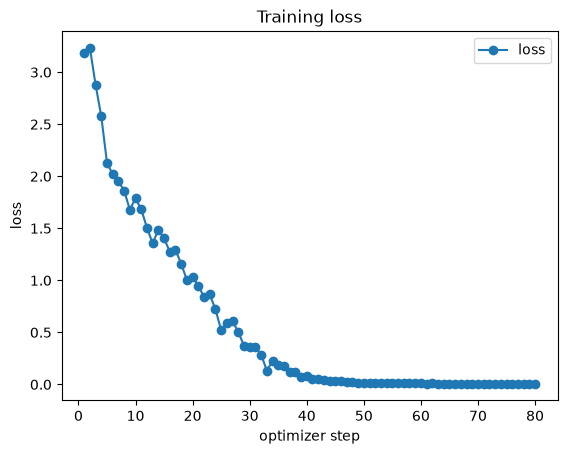

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 11. After 응답 비교


In [16]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q, max_new_tokens=200, do_sample=True)
    print(f"\nQ: {q}")
    print(f"[Before]\n {before_answers[q]}")
    print("-" * 50)
    print(f"[After ]\n {after_ans}")
    print("=" * 50)


Before vs After 비교

Q: 직무: Vision AI모델 개발자 경험: opencv, pytorch, labelme를 사용해 모델 라벨링부터 모델 파인튜닝을 진행했다.
[Before]
 안녕하세요! 당신은 **Vision AI 모델 개发자**로서 **OpenCV**, **PyTorch**, **LabelMe**를 활용한 **라벨링 → 모델 훈련 → 파인트튜닝** 과정을 경험하셨습니다. 이 경험을 바탕으로 다양한 기술적 역량과 프로젝트 경험을 보유하고 있습니다.

---

### ✅ 주요 역량 및 경험 요약:

1. **라ベル링 (Annotation)**
   - OpenCV와 LabelMe를 활용하여 이미지 데이터에 �
--------------------------------------------------
[After ]
 1. 데이터 수집과 라ベル링 작업에서 어떤 도구를 사용했나요?
2. 토큰화 규칙을 어떻게 설계하겠습니까?
3. 학습용 데이터와 검증용 데이터가 어떻게 구분되었나요？
4. loss function에 어떤 지표를 넣겠습니까？
5. 핀트unning 전략과 학력 조정이 어떻게 되나요？

Q: 직무: AI 엔지니어 경험: pytorch를 사용해 모델을 설계하고 모델에 맞는 평가지표를 직접 만들어 평가하였다.
[Before]
 안녕하세요! 당신은 AI 엘리먼트에서 PyTorch를 활용하여 모델 설계와 평가는 경험을 가지고 있습니다. 이 경험을 바탕으로, 아래에 **PyTorch로 모델 구축 및 평사지표 개발**에 대한 설명과 함께 **이력서/자기소개** 형식의 예시를 제공합니다.

---

## ✅ **이력을 정리한 자소**

**직무:** AI 엄니어  
**경험:**  
- **Pytorch 기반 모델 개
--------------------------------------------------
[After ]
 1. 모델 성능이 예측 불확실한 작업에서 어떤 평도사ัย를 적용하겠습니까?
2. 지연시간과 정확도 사이의 trade-of

## 12. 어댑터 저장

QLoRA에서는 전체 모델이 아니라 LoRA adapter만 저장합니다.


In [17]:
ADAPTER_DIR = "./lora_adapters/sample_qlora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/sample_qlora


## 13. 문제가 계속될 때 보는 체크리스트

- `LoRA params > 0`인데 `Trainable LoRA params = 0`이면 `ensure_lora_trainable()` 셀을 확인하세요.
- `decoded labels`에 질문이 많이 보이면 `train_dataset = full_dataset.select_columns(["prompt", "completion"])`와 `completion_only_loss=True`를 확인하세요.
- 40개 데이터에서는 loss가 step마다 출렁입니다. 10 step 안팎으로 판단하지 말고 80~160 step 추세를 보세요.
- LoRA 설정 셀을 중복 실행하면 adapter가 꼬일 수 있습니다. 이상하면 커널 재시작 후 위에서부터 다시 실행하세요.
- 모델 ID를 바꿨는데 `target_modules` 에러가 나면 `target_modules="all-linear"`로 바꿔 시도하세요.
